# Quick Start

This tutorial introduces the core principles of hyperalignment through matrix-level examples. Although `fMRI-HA` provides high-level pipeline functions for routine analyses, working through the underlying operations makes the transformation mechanism more transparent and helps users understand how common spaces are constructed and how the Transformation Matrix (T matrix) is estimated.

## 1. Background and Motivation: From Voxel Coordinates to Shared Representational Geometry

```{image} pic/introduction/t1_fig1_n.png
:width: 800px
```


In the schematic illustration above, the blue and orange trajectories represent multivoxel response patterns from two individuals within the same small cortical region, here simplified to a three-voxel space. Each point along a trajectory corresponds to the activity pattern evoked at a given time point or stimulus moment. Although the two individuals are exposed to the same stimulus and may encode similar information, their response trajectories are expressed in different voxel coordinate systems.

This discrepancy is a central challenge for multivariate fMRI analysis. Within a local cortical region, different individuals may preserve a broadly similar representational geometry: stimuli that are similar for one participant may also be similar for another, and the overall structure of distances, clusters, and similarity relationships may be partially shared across brains. However, this shared geometry is embedded in subject-specific voxel bases. In other words, the same information may be represented through different linear combinations of voxels across individuals. As a result, direct voxel-by-voxel comparisons can confound representational differences with differences in how each individual’s functional topography is expressed in voxel space.

Hyperalignment was developed to address this problem. Rather than assuming that the same voxel index corresponds to the same functional dimension across individuals, hyperalignment estimates transformations that bring subject-specific representational spaces into a shared coordinate system. The goal is not to alter the internal geometry of each participant’s response patterns, but to re-express that geometry in a common information space. After alignment, response patterns evoked by the same stimulus should occupy more comparable positions across individuals, while the pairwise relationships among patterns within each individual are largely preserved.

In this tutorial, we focus on hyperalignment based on orthogonal Procrustes rotation. Under this formulation, each subject’s data are mapped to a target or common representational space using an orthogonal transformation. Because orthogonal transformations rotate or reflect the coordinate system without changing distances and angles within the original point cloud, they provide a transparent way to align representational spaces while preserving their internal structure.

It is important to note that the resulting common space should not be interpreted as a set of explicitly labeled psychological or semantic dimensions. Instead, it is a shared information coordinate system constructed through cross-subject alignment. The key assumption is that the geometry of stimulus-evoked response patterns is at least partly shared across individuals, whereas its expression in voxel coordinates is subject specific. Procrustes-based hyperalignment therefore aligns the expression of a shared representational geometry across different voxel bases, enabling more meaningful comparison of multivariate response patterns across brains.

## 2. Procrustes Rotation: The Core Mechanism of Hyperalignment

### Mathematical Formulation of Procrustes Rotation

Procrustes-based hyperalignment is built on a simple geometric principle: response patterns that encode similar information may have similar internal representational structure, even when they are expressed in different voxel coordinate systems across individuals. Directly comparing voxel-wise activity patterns can therefore be misleading, because apparent differences may arise from subject-specific functional topographies rather than from differences in the underlying represented information.

Procrustes rotation addresses this problem by estimating a rigid transformation that reorients one representational space to match another. In the context of hyperalignment, the goal is not to change the internal geometry of an individual’s response patterns, but to express that geometry in a coordinate system that is more comparable across subjects.

An important feature of this transformation is that it is constrained to be orthogonal, allowing rotation and, depending on the formulation, reflection. This constraint preserves the geometry of the data, including pairwise distances, angles, and inner-product relationships among multivoxel response patterns. Procrustes rotation is therefore well suited to hyperalignment: it can reduce inter-subject variability arising from idiosyncratic voxel bases while preserving the representational structure carried by each subject’s response patterns.

Formally, let

$$
X \in \mathbb{R}^{T \times V}
\quad \text{and} \quad
Y \in \mathbb{R}^{T \times V}
$$

denote two multivoxel response matrices measured over the same set of $T$ time points or matched stimulus samples, with $V$ voxels or features. Here, $X$ may represent the data from one subject, while $Y$ may represent another subject or a reference common space. Orthogonal Procrustes alignment seeks a T matrix

$$
R \in \mathbb{R}^{V \times V}
$$

that maps $X$ toward $Y$ by minimizing the squared Frobenius norm of the residual mismatch:

$$
\min_{R}\; \|XR - Y\|_F^2
\quad \text{subject to} \quad
R^\top R = I .
$$

Here, $\|\cdot\|_F$ denotes the Frobenius norm, which measures the overall discrepancy between the transformed source data $XR$ and the target data $Y$. The orthogonality constraint $R^\top R = I$ ensures that the transformation does not arbitrarily stretch, shrink, or shear the original data. Instead, it only reorients the voxel basis, thereby preserving the internal geometry of the source representational space.

This formulation captures the central role of Procrustes rotation in hyperalignment. It provides a principled way to align subject-specific representational spaces by correcting differences in their voxel-coordinate expression, rather than imposing direct voxel-wise correspondence. The resulting aligned data can then be compared in a shared information space, where response patterns evoked by the same stimuli are expected to be more geometrically comparable across individuals.

In the next subsection, we show that this optimization problem has a closed-form solution based on singular value decomposition (SVD), which makes Procrustes-based hyperalignment both computationally efficient and transparent at the matrix level.

### Single-ROI Example

**Computing the Procrustes T matrix**

We first illustrate Procrustes-based alignment in a single ROI or local voxel set. The function `procrustes()` estimates a T matrix `R` that maps the source data matrix `X` as closely as possible to the target data matrix `Y` under a Procrustes framework. Here, `X` and `Y` are assumed to contain matched response samples, such as the same time points or stimulus events, and the columns correspond to voxels or features within the ROI.

The returned T matrix `R` can then be applied to `X`, for example as `X_aligned = X @ R`, to express the source response patterns in the target representational space defined by `Y`.

The optional arguments `reflection` and `scaling` specify which class of transformations is allowed.

- **`reflection`**  
  Specifies whether reflections are allowed in addition to rotations.

  - When `reflection=True`, the transformation may include a reflection, allowing the solution to flip one or more axes when doing so improves the match between `X` and `Y`.
  - When `reflection=False`, the transformation is restricted to proper rotations, thereby preserving the orientation of the coordinate system.

  In many hyperalignment applications, reflections are allowed because they preserve distances and angles among response patterns and can improve alignment when the directions of representational axes differ across individuals.

- **`scaling`**  
  Specifies whether isotropic scaling is allowed.

  - When `scaling=True`, the transformation may include a global rescaling factor in addition to rotation or reflection.
  - When `scaling=False`, the transformation preserves the scale of the source representational space.

  In standard hyperalignment, scaling is typically disabled (`scaling=False`) so that alignment reflects a reorientation of representational axes rather than a change in overall response magnitude.

Unless otherwise specified, the tutorials in this section use `reflection=True` and `scaling=False`. This setting yields an orthogonal Procrustes transformation that preserves the geometry of multivoxel response patterns while allowing subject-specific voxel axes to be reoriented into a common representational space.

Subject 1 data shape: (451, 119)
Subject 2 data shape: (451, 119)
Data input: 451 timepoint, 119 node, 2 subjects
Data input: 451 timepoint, 119 node, 2 subjects
Mean ISC before Procrustes alignment: 0.0143
Mean ISC after Procrustes alignment:  0.2592


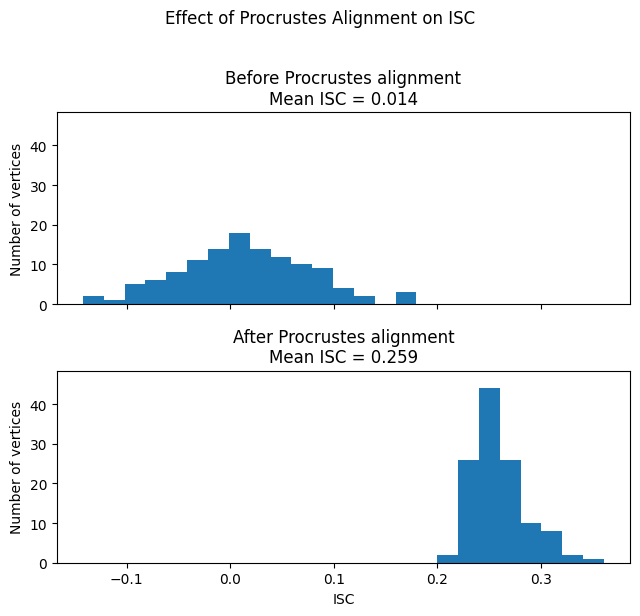

In [ ]:
import os
# --------------------------------------------------
# (Optional) Limit the number of threads used by BLAS
# This is recommended on Linux to avoid oversubscription
# when running searchlight computations in parallel.
# --------------------------------------------------
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from fmriha.src.procrustes import procrustes
from fmriha.stat.isc import isc_mat_nb


# ---------------------------------------------------------------------
# Set paths and load data
# ---------------------------------------------------------------------
subject_dir = Path("/path/to/raw_data/subject_sl")

# Each array has shape: n_timepoints x n_vertices
sub1 = np.load(subject_dir / "sub1_sl.npy")
sub2 = np.load(subject_dir / "sub2_sl.npy")

print(f"Subject 1 data shape: {sub1.shape}")
print(f"Subject 2 data shape: {sub2.shape}")


# ---------------------------------------------------------------------
# Estimate and apply the Procrustes transformation
# ---------------------------------------------------------------------

# Align subject 1 to subject 2.
# X is the source data and Y is the target data.
R = procrustes(
    X=sub1,
    Y=sub2,
    reflection=True,
    scaling=False
)

# Apply the T matrix to the source data.
sub1_aligned = sub1 @ R


# ---------------------------------------------------------------------
# Compute ISC before and after Procrustes alignment
# ---------------------------------------------------------------------

def compute_mean_isc(data_a, data_b):
    """Compute vertex-wise mean ISC between two subjects."""
    data = np.stack([data_a, data_b], axis=2)

    result = isc_mat_nb(
        mat=data,
        pairwise=True,
        metric="correlation",
        n_jobs=1,
        summary_statistic="mean"
    )

    return result["ISC_mean"]


isc_raw = compute_mean_isc(sub1, sub2)
isc_aligned = compute_mean_isc(sub1_aligned, sub2)

print(f"Mean ISC before Procrustes alignment: {isc_raw.mean():.4f}")
print(f"Mean ISC after Procrustes alignment:  {isc_aligned.mean():.4f}")


# ---------------------------------------------------------------------
# Visualize ISC distributions
# ---------------------------------------------------------------------

def plot_isc_histograms(
    isc_before,
    isc_after,
    bins=25,
    title="Single-ROI Procrustes Alignment",
):
    """Plot ISC distributions before and after Procrustes alignment."""
    isc_before = np.asarray(isc_before)
    isc_after = np.asarray(isc_after)

    xmin = min(isc_before.min(), isc_after.min())
    xmax = max(isc_before.max(), isc_after.max())

    hist_before, _ = np.histogram(isc_before, bins=bins, range=(xmin, xmax))
    hist_after, _ = np.histogram(isc_after, bins=bins, range=(xmin, xmax))
    ymax = max(hist_before.max(), hist_after.max())

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(6.5, 6),
        sharex=True,
        sharey=True
    )

    plot_items = [
        (axes[0], isc_before, "Before Procrustes alignment"),
        (axes[1], isc_after, "After Procrustes alignment")
    ]

    for ax, values, panel_title in plot_items:
        mean_value = values.mean()

        ax.hist(values, bins=bins, range=(xmin, xmax))
        ax.set_ylabel("Number of vertices")
        ax.set_title(f"{panel_title}\nMean ISC = {mean_value:.3f}")
        ax.set_ylim(0, ymax * 1.10)

    axes[1].set_xlabel("ISC")
    fig.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()


plot_isc_histograms(
    isc_before=isc_raw,
    isc_after=isc_aligned,
    bins=25,
    title="Effect of Procrustes Alignment on ISC"
)

## 3. Constructing a Common Representational Space

```{image} pic/introduction/t1_fig2_n.png
:width: 800px
```

The goal of hyperalignment is not merely to align one subject to another, but to re-express individual neural response patterns in a **common representational space**. This space provides a shared coordinate system in which multivoxel activity patterns from different individuals can be compared, averaged, decoded, or modelled in a more meaningful way.

This step is necessary because fine-scale functional organization varies across individuals. Even when different participants encode similar stimulus-related information, that information may be expressed through different voxel axes or voxel combinations. Direct comparison in native voxel space can therefore obscure shared representational structure. By mapping each individual’s data into a common space, hyperalignment reduces subject-specific differences in voxel-coordinate expression while preserving the internal geometry of each individual’s response patterns. As a result, response patterns evoked by the same stimulus or time point become more comparable across individuals.

In practice, the common space serves as a reference frame for cross-subject multivariate analyses, including pattern averaging, between-subject decoding, inter-subject correlation, and representational similarity analysis. Importantly, the common space should not be interpreted as a set of explicitly labeled psychological or semantic dimensions. Rather, it is a group-level information coordinate system constructed to capture representational structure shared across subjects.

Several strategies can be used to construct such a common representational space. The current toolbox supports Procrustes-based approaches, which iteratively align subject-specific response spaces to a shared template, as well as PCA-based methods, which derive a common low-dimensional structure from the group data. These alternatives allow users to choose an alignment strategy according to the goals and constraints of their analysis.

### Iterative Template Construction with Procrustes Rotation

```{image} pic/introduction/t1_fig3_n.png
:width: 1000px
```

In practice, a common representational space in Procrustes-based hyperalignment is often constructed using an **iterative template algorithm**. Rather than treating a single subject as the final reference space, the algorithm progressively aligns individual subjects into a shared coordinate system and updates the group template based on the aligned data.

As illustrated in the schematic above, this procedure can be understood as a two-stage process.

**First stage: sequential alignment and template initialization.**  
One subject is first selected as an initial reference space. A second subject is aligned to this reference using Procrustes rotation, and the aligned data are averaged with the reference data to form an interim template. Additional subjects are then aligned one by one to the current template, and the template is updated after each alignment by averaging the newly aligned data with the previously aligned data. After all subjects have been processed once, this procedure yields an initial, or first-pass, common template.

**Second stage: refinement using the first-pass template.**  
In the second pass, all subjects' original data are independently realigned to the first-pass template. The resulting aligned response matrices are then averaged across subjects to produce the final common representational space. This refinement step reduces potential bias introduced by the initial reference subject and produces a group-level template that is derived from all subjects rather than from any single individual.

Formally, let

$$
B_i \in \mathbb{R}^{T \times V}
$$

denote the response matrix of subject $i$, where $T$ is the number of matched time points or stimulus samples and $V$ is the number of voxels or features. Let

$$
R_i \in \mathbb{R}^{V \times V}
$$

denote the subject-specific orthogonal transformation estimated by Procrustes alignment. Given a current template $M$, each subject-specific transformation can be estimated as

$$
R_i
=
\arg\min_{R}
\left\| B_i R - M \right\|_F^2
\quad
\text{subject to}
\quad
R^\top R = I .
$$

After aligning all subjects to the current template, the template is updated by averaging the transformed response matrices:

$$
M
=
\frac{1}{N}
\sum_{i=1}^{N}
B_i R_i .
$$

In an iterative implementation, these two steps are repeated: subject-specific transformations are estimated relative to the current template, and the template is then recomputed from the aligned data. The final common space therefore reflects the shared representational geometry supported by the group, while each subject retains a separate mapping into that space.

Importantly, although the initial coordinate system may be anchored by a reference subject, the final common model space is not simply that subject's native space. It is a group-derived representational template. Even the initial reference subject can receive a non-identity transformation during refinement, because the final template is recomputed from the aligned data of all subjects.

In [2]:
from fmriha.src.local_template import compute_template


# ---------------------------------------------------------------------
# Load data from multiple subjects
# ---------------------------------------------------------------------

# Each array has shape: n_timepoints x n_vertices
sub1 = np.load(subject_dir / "sub1_sl.npy")
sub2 = np.load(subject_dir / "sub2_sl.npy")
sub3 = np.load(subject_dir / "sub3_sl.npy")

print(f"Subject 1 data shape: {sub1.shape}")
print(f"Subject 2 data shape: {sub2.shape}")
print(f"Subject 3 data shape: {sub3.shape}")


# ---------------------------------------------------------------------
# Construct a Procrustes-based common template
# ---------------------------------------------------------------------

# Stack subject data into a single array with shape:
# n_subjects x n_timepoints x n_vertices
dss = np.stack([sub1, sub2, sub3], axis=0)

print(f"Stacked data shape: {dss.shape}")

# Compute the common template using Procrustes-based hyperalignment.
# The argument sl=None indicates that the full input ROI/local voxel set is used.
M_pr = compute_template(
    dss=dss,
    sl=None,
    kind="procrustes"
)

print(f"Common template shape: {M_pr.shape}")

Subject 1 data shape: (451, 119)
Subject 2 data shape: (451, 119)
Subject 3 data shape: (451, 119)
Stacked data shape: (3, 451, 119)
Common template shape: (451, 119)


### Common Space Construction with PCA

```{image} pic/introduction/t1_fig4_n.png
:width: 600px
```

In addition to Procrustes-based iterative alignment, a common representational space can also be constructed using a **PCA-based approach**. Instead of building the template through sequential subject-to-template alignment, this approach estimates shared structure by applying dimensionality reduction to the group data. The resulting components capture dominant patterns of variance across subjects and provide a group-derived basis for constructing a common template.

A key advantage of the PCA-based approach is that all subjects contribute to the decomposition simultaneously. As a result, the initial estimation of the common structure is less dependent on subject ordering than sequential Procrustes-based template construction.

The PCA-based procedure can be understood in three conceptual steps.

**Step A: Estimate a PCA-based group template.**  
Response matrices from all subjects are combined along the feature dimension, and singular value decomposition (SVD) is applied to the concatenated data. A subset of principal components is retained to form a low-dimensional template, denoted as $M_{\mathrm{PC}}$, which captures the dominant response structure shared across subjects.

**Step B: Express the PCA template in the original feature space.**  
The PCA-derived template is initially defined in a reduced component space. To make it compatible with subject-level voxel or vertex data, the template can be mapped back to the original feature space. In this step, an orthogonal Procrustes transformation is estimated to best match the PCA-derived template to the subject data:

$$
R =
\arg\min_{R}
\sum_{p=1}^{N}
\left\|
M_{\mathrm{PC}} R - B_p
\right\|_F^2
\quad
\text{subject to}
\quad
R^\top R = I .
$$

Here, $B_p \in \mathbb{R}^{T \times V}$ denotes the response matrix of subject $p$, where $T$ is the number of matched time points or stimulus samples and $V$ is the number of voxels or vertices. In this context, Procrustes rotation is used as a projection or reconstruction step: it helps express the PCA-derived shared structure in the original feature space, rather than serving as the primary mechanism by which the common structure is estimated.

**Step C: Aggregate the projected representations.**  
After the PCA-derived template has been expressed in the feature space, the resulting representations can be aggregated to form the final common template. This template can then be used as a reference space for subsequent hyperalignment, transformation estimation, or cross-subject multivariate analyses.

Overall, the PCA-based approach provides an alternative strategy for common space construction. By estimating shared structure through a group-level decomposition, it reduces sensitivity to subject ordering while still producing a template that can be related back to the original voxel or vertex space.

In [3]:
# common_topography=True projects the PCA template back into vertex/voxel space.
M_pca = compute_template(dss, sl=None, kind="pca", common_topography=True)
print(f"Common template shape: {M_pca.shape}")

Common template shape: (451, 119)


## 4. T matrices

After constructing a common representational space, the next step is to estimate subject-specific T matrices. These matrices define how each subject's raw response data can be mapped into the common space. In Procrustes-based hyperalignment, each T matrix is estimated using the orthogonal Procrustes procedure introduced in Section 2.

Once estimated, the T matrices can be applied to new or held-out fMRI data from the same subjects. This allows response patterns originally expressed in subject-specific voxel or vertex coordinates to be re-expressed in the shared common space, enabling cross-subject comparison, averaging, decoding, or other multivariate analyses.

### Estimating subject-specific T matrices

In [4]:
# ---------------------------------------------------------------------
# Estimate subject-specific T matrices
# ---------------------------------------------------------------------

# Estimate transformations from each subject's raw data to the
# PCA-based common space.
sub1_pca_R = procrustes(X=sub1, Y=M_pca)
sub2_pca_R = procrustes(X=sub2, Y=M_pca)
sub3_pca_R = procrustes(X=sub3, Y=M_pca)

# Estimate transformations from each subject's raw data to the
# Procrustes-based common space.
sub1_pr_R = procrustes(X=sub1, Y=M_pr)
sub2_pr_R = procrustes(X=sub2, Y=M_pr)
sub3_pr_R = procrustes(X=sub3, Y=M_pr)

### Alignment

Data input: 451 timepoint, 119 node, 3 subjects
Data input: 451 timepoint, 119 node, 3 subjects
Data input: 451 timepoint, 119 node, 3 subjects
Mean raw ISC: 0.0147
Mean ISC after PCA-based common-space alignment: 0.2117
Mean ISC after Procrustes-based common-space alignment: 0.2380


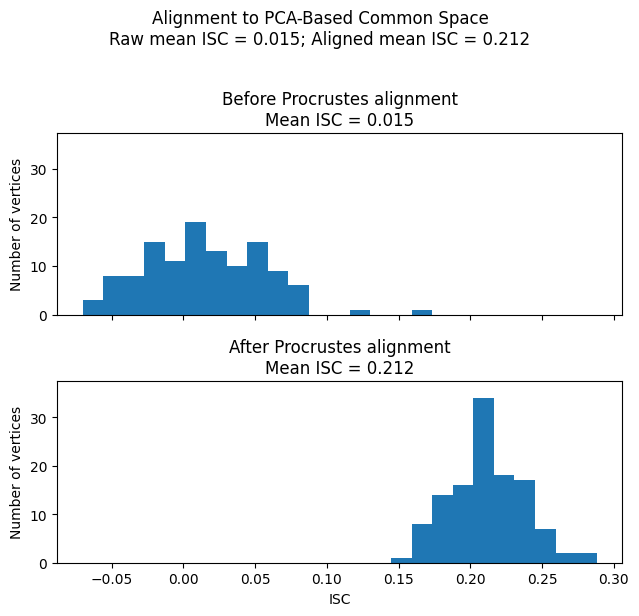

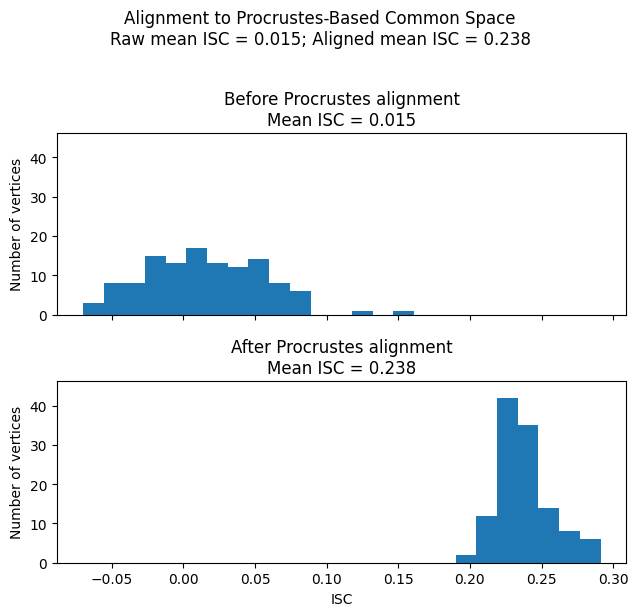

In [5]:
# ---------------------------------------------------------------------
# Apply T matrices to subject data
# ---------------------------------------------------------------------

# Align each subject to the PCA-based common space.
sub1_pca_aligned = sub1 @ sub1_pca_R
sub2_pca_aligned = sub2 @ sub2_pca_R
sub3_pca_aligned = sub3 @ sub3_pca_R

# Align each subject to the Procrustes-based common space.
sub1_pr_aligned = sub1 @ sub1_pr_R
sub2_pr_aligned = sub2 @ sub2_pr_R
sub3_pr_aligned = sub3 @ sub3_pr_R


# ---------------------------------------------------------------------
# Compute ISC before and after alignment
# ---------------------------------------------------------------------

# ISC in the original subject-specific space.
mat_raw = np.stack([sub1, sub2, sub3], axis=2)
isc_raw = isc_mat_nb(
    mat=mat_raw,
    pairwise=True,
    metric="correlation",
    n_jobs=1,
    summary_statistic="mean",
)["ISC_mean"]

# ISC after alignment to the PCA-based common space.
mat_pca = np.stack(
    [sub1_pca_aligned, sub2_pca_aligned, sub3_pca_aligned],
    axis=2
)
isc_pca = isc_mat_nb(
    mat=mat_pca,
    pairwise=True,
    metric="correlation",
    n_jobs=1,
    summary_statistic="mean",
)["ISC_mean"]

# ISC after alignment to the Procrustes-based common space.
mat_pr = np.stack(
    [sub1_pr_aligned, sub2_pr_aligned, sub3_pr_aligned],
    axis=2
)
isc_pr = isc_mat_nb(
    mat=mat_pr,
    pairwise=True,
    metric="correlation",
    n_jobs=1,
    summary_statistic="mean",
)["ISC_mean"]

print(f"Mean raw ISC: {isc_raw.mean():.4f}")
print(f"Mean ISC after PCA-based common-space alignment: {isc_pca.mean():.4f}")
print(f"Mean ISC after Procrustes-based common-space alignment: {isc_pr.mean():.4f}")


# ---------------------------------------------------------------------
# Visualize ISC distributions
# ---------------------------------------------------------------------

plot_isc_histograms(
    isc_before=isc_raw,
    isc_after=isc_pca,
    bins=25,
    title=(
        "Alignment to PCA-Based Common Space\n"
        f"Raw mean ISC = {isc_raw.mean():.3f}; "
        f"Aligned mean ISC = {isc_pca.mean():.3f}"
    )
)

plot_isc_histograms(
    isc_before=isc_raw,
    isc_after=isc_pr,
    bins=25,
    title=(
        "Alignment to Procrustes-Based Common Space\n"
        f"Raw mean ISC = {isc_raw.mean():.3f}; "
        f"Aligned mean ISC = {isc_pr.mean():.3f}"
    )
)

## 5. From Single-ROI Alignment to Searchlight Hyperalignment
### Conceptual Overview of Searchlight Hyperalignment

```{image} pic/introduction/t1_fig5_n.png
:width: 800px
```

The examples above illustrate hyperalignment within a single ROI or local voxel set. In practical whole-brain applications, the same logic is extended to a dense set of local neighborhoods, or **searchlights**, distributed across the cortical surface or brain volume.

In searchlight-based hyperalignment, each searchlight defines a local multivariate response space. Within this local space, response patterns from different subjects are aligned by constructing a local common space and estimating subject-specific T matrices. This procedure follows the representational-space framework introduced by Haxby and colleagues: instead of assuming one-to-one voxel correspondence across subjects, hyperalignment aligns local representational geometries across individuals.

The procedure is repeated independently for many overlapping searchlights across the brain. Because searchlights overlap, each voxel or surface vertex can belong to multiple local neighborhoods and can therefore receive multiple locally estimated transformations. Rather than selecting a single transformation, these local mappings are combined to form a voxel-wise or vertex-wise transformation. In many implementations, this aggregation is performed using distance-based weighting, so that searchlights centered closer to a given voxel or vertex contribute more strongly to its final transformation.

Through this local-to-global aggregation, searchlight hyperalignment produces a whole-brain mapping from each subject's native representational space into a shared common space. Applying the resulting transformations to fMRI data allows individual response patterns to be re-expressed in a common coordinate system, while still respecting the local structure of multivariate representations. This makes it possible to compare, average, decode, or model response patterns across individuals despite substantial variability in fine-scale cortical organization.

### Defining Searchlights and Constructing Local Common Spaces

To perform searchlight-based hyperalignment, the first step is to define a set of searchlights that tile the cortical surface or brain volume. In this tutorial, we use the `neuroboros` package to load a predefined searchlight list for convenience, rather than constructing searchlights manually.

The response data are assumed to be organized as a matrix with shape `nt × nv`, where `nt` denotes the number of time points and `nv` denotes the number of vertices or voxels. In the demonstration below, the data matrix has shape `451 × 9675`, corresponding to the left hemisphere after removing the medial wall.

A searchlight list is represented as a list of index arrays. Each element of the list defines one local neighborhood. For example, a searchlight list such as `[[1, 2, 3], [4, 5, 6], ...]` indicates that the first searchlight contains vertices `1`, `2`, and `3`, while the second searchlight contains vertices `4`, `5`, and `6`. In practice, each searchlight usually contains a larger set of nearby vertices or voxels defined by a spatial radius or neighborhood rule.

During searchlight hyperalignment, the common-space construction and T matrix estimation steps introduced above are repeated independently within each searchlight. That is, for each local neighborhood, the toolbox extracts the corresponding response data, constructs a local common representational space, and estimates subject-specific transformations into that local space. These local results can then be combined across overlapping searchlights to produce a whole-brain alignment.

The code below provides a compact implementation of this procedure and is intended to make the computational logic transparent. It is generally suitable for educational purposes, exploratory analyses, and small- to moderate-sized datasets. For larger datasets, however, this direct implementation may become computationally expensive in terms of runtime, memory usage, and intermediate file handling.

For large-scale applications, or for analyses requiring more advanced customization such as alternative weighting schemes, chunked computation, or optimized parallel execution, users should rely on the higher-level computational modules provided by the toolbox. These modules build on the same principles introduced here, but provide additional utilities and optimizations for full-scale searchlight-based hyperalignment.

In [ ]:
from pathlib import Path
import neuroboros as nb
import numpy as np
from fmriha.src.searchlight import searchlight_template


subject_dir = Path("/path/to/raw_data/subject_left_hemi")

# Each array has shape: n_timepoints x n_vertices
sub1_data = np.load(subject_dir / "sub1_left.npy")
sub2_data = np.load(subject_dir / "sub2_left.npy")
sub3_data = np.load(subject_dir / "sub3_left.npy")

print(f"Subject 1 data shape: {sub1_data.shape}")
print(f"Subject 2 data shape: {sub2_data.shape}")
print(f"Subject 3 data shape: {sub3_data.shape}")


# ---------------------------------------------------------------------
# Stack data across subjects
# ---------------------------------------------------------------------

# Resulting shape: n_subjects x n_timepoints x n_vertices
dss = np.stack([sub1_data, sub2_data, sub3_data], axis=0)
print(f"Stacked data shape: {dss.shape}")


# ---------------------------------------------------------------------
# Load predefined surface searchlights
# ---------------------------------------------------------------------

# sls:
#     A list of searchlights. Each element contains the vertex indices
#     belonging to one local searchlight.
#
# dists:
#     A list of vertex-to-center distances for each searchlight.
#     These distances can be used later for distance-weighted aggregation.

radius = 20
sls, dists = nb.sls(lr="l", radius=radius, space="onavg-ico32", return_dists=True)

print(f"Number of searchlights: {len(sls)}")
print(f"Example searchlight size: {len(sls[0])}")


# ---------------------------------------------------------------------
# Construct searchlight-wise common representational spaces
# ---------------------------------------------------------------------

# Here, tmpl_kind="pca" constructs a PCA-based common space within
# each searchlight. The same function can be used with other template
# construction strategies if supported by the toolbox.
M_sls = searchlight_template(
    dss=dss,
    sls=sls,
    dists=dists,
    radius=radius,
    n_jobs=10,
    tmpl_kind="pca"
)

print(f"Number of local common spaces: {len(M_sls)}")

Subject 1 data shape: (451, 9675)
Subject 2 data shape: (451, 9675)
Subject 3 data shape: (451, 9675)
Stacked data shape: (3, 451, 9675)
Number of searchlights: 9675
Example searchlight size: 119


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    4.1s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    4.8s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    5.8s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:    7.3s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:    9.2s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:   11.4s
[Parallel(n_jobs=10)]: Done 2430 tasks      | elapsed:   14.2s
[Parallel(n_jobs=10)]: Done 3180 tasks      | elapsed:   17.3s
[Parallel(n_jobs=10)]: Done 4030 tasks      | elapsed:   20.9s
[Parallel(n_jobs=10)]: Done 4980 tasks      | elapsed:   24.8s
[Parallel(n_jobs=10)]: Done 6030 tasks      | elapsed:   29.3s
[Parallel(n_jobs=10)]: Done 7180 tasks      | elapsed:   34.1s
[Parallel(n_jobs=10)]: Done 8430 tasks      | elapsed:   39.4s
[Parallel(n_jobs=10)]: Done 9675 out of 9675 | elapsed:   44.6s finished


Number of local common spaces: 451


### Estimating and aggregating searchlight T matrices

After constructing local common spaces for each searchlight, the next step is to estimate subject-specific T matrices within each local neighborhood. For a given searchlight, each subject's response data are aligned to the corresponding local common space using Procrustes rotation, yielding a local T matrix for that subject.

Because searchlights overlap, each voxel or vertex can be associated with multiple local transformations estimated from neighboring searchlights. These local transformations are therefore aggregated to obtain a whole-brain transformation for each subject. In practice, this aggregation can be performed using distance-based weighting, so that searchlights centered closer to a given voxel or vertex contribute more strongly to its final transformation.

The resulting subject-specific whole-brain T matrices can then be applied to raw or held-out fMRI data, allowing each subject's response patterns to be expressed in the shared common representational space.

In the following example, we estimate local T matrices for each searchlight and aggregate them into subject-specific whole-brain transformations.

The `searchlight_procrustes` function does not perform internal parallelization.

Data input: 451 timepoint, 9675 node, 3 subjects
Data input: 451 timepoint, 9675 node, 3 subjects
Mean ISC before searchlight alignment: 0.0680
Mean ISC after searchlight alignment:  0.3256


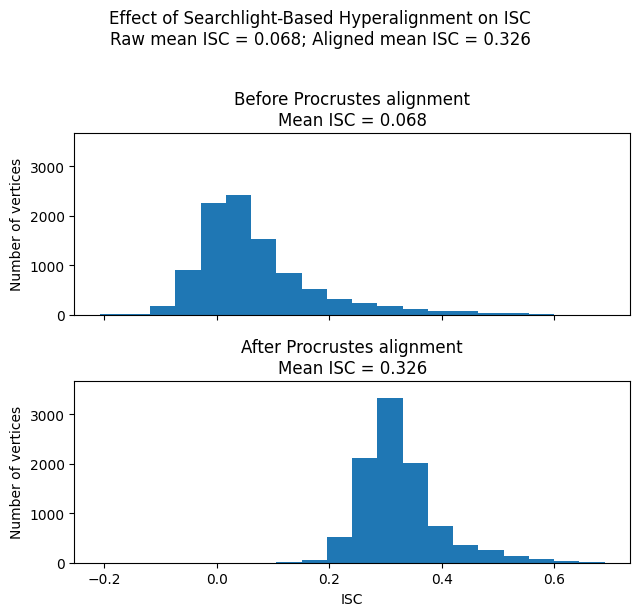

In [7]:
from fmriha.src.searchlight import searchlight_procrustes


# ---------------------------------------------------------------------
# Estimate searchlight-based T matrices
# ---------------------------------------------------------------------

# Estimate subject-specific T matrices by aligning each
# subject's data to the searchlight-wise common spaces.
sub1_R_sls = searchlight_procrustes(sub1_data, M_sls, sls, dists, radius)
sub2_R_sls = searchlight_procrustes(sub2_data, M_sls, sls, dists, radius)
sub3_R_sls = searchlight_procrustes(sub3_data, M_sls, sls, dists, radius)


# ---------------------------------------------------------------------
# Apply T matrices to subject data
# ---------------------------------------------------------------------

# Apply the aggregated searchlight T matrix to each subject.
sub1_aligned_left = sub1_data @ sub1_R_sls
sub2_aligned_left = sub2_data @ sub2_R_sls
sub3_aligned_left = sub3_data @ sub3_R_sls


# ---------------------------------------------------------------------
# Compute ISC before and after searchlight hyperalignment
# ---------------------------------------------------------------------

def compute_group_isc(data_list, n_jobs=1):
    """Compute vertex-wise mean ISC across multiple subjects."""
    data = np.stack(data_list, axis=2)

    result = isc_mat_nb(
        mat=data,
        pairwise=False,
        metric="correlation",
        n_jobs=n_jobs,
        summary_statistic="mean"
    )

    return np.nan_to_num(result["ISC_mean"], nan=0.0)


# ISC in the original subject-specific space.
isc_raw = compute_group_isc([sub1_data, sub2_data, sub3_data], n_jobs=10)

# ISC after searchlight-based alignment.
isc_aligned = compute_group_isc([sub1_aligned_left, sub2_aligned_left, sub3_aligned_left], n_jobs=10)

print(f"Mean ISC before searchlight alignment: {isc_raw.mean():.4f}")
print(f"Mean ISC after searchlight alignment:  {isc_aligned.mean():.4f}")


# ---------------------------------------------------------------------
# Visualize ISC distributions
# ---------------------------------------------------------------------

plot_isc_histograms(
    isc_before=isc_raw,
    isc_after=isc_aligned,
    bins=20,
    title=(
        "Effect of Searchlight-Based Hyperalignment on ISC\n"
        f"Raw mean ISC = {isc_raw.mean():.3f}; "
        f"Aligned mean ISC = {isc_aligned.mean():.3f}"
    )
)

### Surface Searchlights

Surface searchlights can be generated in two ways. The first option is to use the predefined searchlight lists provided by `neuroboros`, as shown above. This approach is convenient and works well for standard surface spaces. However, `nb.sls()` currently supports only a limited set of predefined spaces, including `onavg-ico32`, `fslr-ico32`, and `fsavg-ico32`, and the searchlight radius should not exceed `20` mm.

The second option is to generate searchlights from user-provided surface data. The `fMRI-HA` toolbox provides functions for constructing surface searchlights based on geodesic distances, following a logic similar to the Dijkstra-based distance computation used in `neuroboros`. This option is useful when working with custom surfaces, non-standard meshes, or surface spaces not covered by the predefined `neuroboros` searchlight lists.

In this section, we first introduce the `neuroboros`-based approach and then describe how to generate searchlights from custom surface data.

The function `nb.sls()` generates a surface-based searchlight list and, optionally, the corresponding distance information. Its key parameters are summarized below.

- **`lr`**  
  Specifies the hemisphere on which searchlights are defined. Use `lr="l"` for the left hemisphere and `lr="r"` for the right hemisphere.

- **`radius`**  
  Defines the radius of each searchlight, typically in millimeters. When using predefined surface spaces in `neuroboros`, the radius should not exceed `20` mm.

- **`space`**  
  Specifies the surface space on which the response data are defined. Common options include `onavg-ico32`, `fslr-ico32`, and `fsavg-ico32`.

- **`center_space`**  
  Controls how searchlight centers are selected and can be used as a downsampling strategy. For example, when `center_space="onavg-ico8"`, searchlight centers are defined on a lower-resolution `ico8` surface, while the searchlights themselves are constructed on the higher-resolution surface specified by `space`.

  In practice, each vertex in the `ico8` surface is used as a searchlight center, and all vertices from the `ico32` surface that fall within the specified radius are included in that searchlight. This reduces the total number of searchlights while preserving coverage of the high-resolution response-data surface, which can substantially reduce computation time.

  Setting `center_space=False` disables center downsampling and uses all vertices in `space` as searchlight centers.

- **`mask`**  
  Specifies whether to exclude masked vertices, such as vertices in the medial wall. When `mask=False`, no additional masking is applied.

- **`return_dists`**  
  Specifies whether to return the distances between vertices and their corresponding searchlight centers. When `return_dists=True`, the function returns both `sls` and `dists`. These distances are typically used for distance-weighted aggregation when combining results from overlapping searchlights.

In [8]:
sls, dists = nb.sls(
    lr="l",               # Hemisphere: "l" or "r"
    radius=20,            # Searchlight radius in millimeters
    space="onavg-ico32",  # Surface space of the response data
    center_space=None,
    mask=False,           # Whether to apply a medial-wall mask
    return_dists=True     # Whether to return vertex-to-center distances
)
print(f"Number of searchlights: {len(sls)}")


Number of searchlights: 10242


The searchlight list generated by `nb.sls()` can be further modified before running hyperalignment. This is useful when you want to exclude the medial wall or restrict the analysis to a specific cortical region.

There are two common options. The first is to apply a cortical mask during searchlight generation by setting `mask=True` in `nb.sls()`. The second is to update an existing searchlight list using the `sls_update()` function provided by the toolbox.

In the example below, `mask=True` applies a predefined cortical mask. For the left hemisphere in the `onavg-ico32` space, this retains `9675` cortical vertices out of the original `10242` vertices.

In [9]:
sls, dists = nb.sls(
    lr="l",
    radius=20,
    space="onavg-ico32",
    center_space=None,
    mask=True,
    return_dists=True
)
print(f"Number of searchlights: {len(sls)}")

Number of searchlights: 9675


In the example below, `sls_update()` is used to remove medial-wall vertices from an existing surface searchlight list.

A key requirement is that the input `sls`, `dists`, and `medial_wall` should be defined over the same full set of vertices. In the example used here, all three objects correspond to the full `onavg-ico32` hemisphere with `10242` vertices before masking. Therefore, if you want to apply your own cortical mask, we recommend generating the initial searchlight list with `mask=False` in `nb.sls()`. This creates a complete searchlight list in the original surface space, which can then be updated consistently using `sls_update()`.

If a mask has already been applied during searchlight generation, the searchlight indices, distance lists, and custom mask may no longer refer to the same vertex indexing system. This can lead to incorrect indexing or inconsistent searchlight updates.

In [ ]:
import joblib
from fmriha import gensls

# ---------------------------------------------------------------------
# Generate unmasked surface searchlights
# ---------------------------------------------------------------------

radius = 20

tmp = {lr: nb.sls(lr, radius, "onavg-ico32", mask=False, return_dists=True) for lr in "lr"}
sls_lr = {lr: tmp[lr][0] for lr in tmp}
dists_lr = {lr: tmp[lr][1] for lr in tmp}


# ---------------------------------------------------------------------
# Load the medial-wall mask
# ---------------------------------------------------------------------
mask_path = Path("/path/to/mask")
medial_wall = joblib.load(mask_path / "onavg32_medial_wall.pkl")


# ---------------------------------------------------------------------
# Update searchlights by removing medial-wall vertices
# ---------------------------------------------------------------------
sls_surf, dists_surf = gensls.sls_update(
    sls=sls_lr,
    dists=dists_lr,
    medial_wall=medial_wall,
    lr="lr",
    center_type="first"
)

print(f"Number of left-hemisphere searchlights:  {len(sls_surf['l'])}")
print(f"Number of right-hemisphere searchlights: {len(sls_surf['r'])}")

Number of left-hemisphere searchlights:  9675
Number of right-hemisphere searchlights: 9666


In addition to using predefined searchlights from `neuroboros`, you can also generate searchlights from your own surface data. This approach is more flexible and is useful when working with custom meshes, non-standard surface spaces, or surfaces that are not directly supported by `nb.sls()`.

In the example below, we first load surface geometry from `.surf.gii` files, including vertex coordinates and face information. We then use these surface data to generate surface-based searchlights for both hemispheres.

In [ ]:
from fmriha import gensls


# ---------------------------------------------------------------------
# Load custom surface geometry
# ---------------------------------------------------------------------

# The .surf.gii files contain surface coordinates and face information.
surface_path = Path("/path/to/surface")

surfgii = {
    lr: surface_path / f"onavg_midthickness_{lr}h.surf.gii"
    for lr in "lr"
}

# Read vertex coordinates and faces from the surface files.
surf_data = gensls.get_surfgii_data(surfgii)


# ---------------------------------------------------------------------
# Generate surface searchlights from custom surface data
# ---------------------------------------------------------------------

radius = 20

sls_lr = {}
dists_lr = {}

for lr in "lr":
    sls_lr[lr], dists_lr[lr] = gensls.generate_searchlight_surf(
        lr=lr,
        surface_file=surf_data,
        center_file=None,
        radius=radius,
        cortical_mask=None
    )

print(f"Number of left-hemisphere searchlights:  {len(sls_lr['l'])}")
print(f"Number of right-hemisphere searchlights: {len(sls_lr['r'])}")

Number of left-hemisphere searchlights:  10242
Number of right-hemisphere searchlights: 10242


Similarly, `generate_searchlight_surf()` also supports cortical masking. When a cortical mask is provided, searchlights are generated only for vertices retained by the mask, and medial-wall vertices can be excluded from the resulting searchlight list.

In the example below, we load a predefined cortical mask for the `onavg-ico32` surface. In this mask, `True` indicates cortical vertices to keep, whereas `False` indicates vertices to exclude, such as medial-wall vertices.

In [13]:
# ---------------------------------------------------------------------
# Generate surface searchlights with a cortical mask
# ---------------------------------------------------------------------

# Load a predefined cortical mask.
# True indicates cortical vertices to keep.
# False indicates vertices to exclude, such as medial-wall vertices.
cortical_mask_lr = joblib.load(mask_path / "onavg32_cortical_mask.pkl")

radius = 20

sls_lr = {}
dists_lr = {}

for lr in "lr":
    sls_lr[lr], dists_lr[lr] = gensls.generate_searchlight_surf(
        lr=lr,
        surface_file=surf_data,
        center_file=None,
        radius=radius,
        cortical_mask=cortical_mask_lr
    )

print(f"Number of left-hemisphere searchlights:  {len(sls_lr['l'])}")
print(f"Number of right-hemisphere searchlights: {len(sls_lr['r'])}")

Number of left-hemisphere searchlights:  9675
Number of right-hemisphere searchlights: 9666


You can also specify a **sparser surface** as the set of searchlight centers to achieve a downsampling effect. In this setting, `surface_file` defines the surface on which the response data are represented, whereas `center_file` defines a lower-resolution surface used only for selecting searchlight centers.

This approach reduces the number of searchlights and therefore lowers computational cost, while the searchlight members are still selected from the higher-resolution surface specified by `surface_file`.

In [ ]:
# ---------------------------------------------------------------------
# Use a sparser surface as searchlight centers
# ---------------------------------------------------------------------
surf_gii = {
    "l": surface_path / "tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii",
    "r": surface_path / "tpl-fsLR_den-32k_hemi-R_midthickness.surf.gii"
}

center_surfgii = {
    "l": surface_path / "tpl-fsLR_den-8k_hemi-L_midthickness.surf.gii",
    "r": surface_path / "tpl-fsLR_den-8k_hemi-R_midthickness.surf.gii"
}

# Load a cortical mask for the high-resolution surface.
cortical_mask = joblib.load(mask_path / "cft_fs57_cortical_mask.pkl")

# Load surface geometry.
# surf_data is used to define searchlight members.
# center_surf_data is used to define searchlight centers.
surf_data = gensls.get_surfgii_data(surf_gii)
center_surf_data = gensls.get_surfgii_data(center_surfgii)

radius = 15

sls_dsample = {}
dists_dsample = {}

for lr in "lr":
    sls_dsample[lr], dists_dsample[lr] = gensls.generate_searchlight_surf(
        lr=lr,
        surface_file=surf_data,
        center_file=center_surf_data,
        radius=radius,
        cortical_mask=cortical_mask
    )

print(f"Number of left-hemisphere searchlights:  {len(sls_dsample['l'])}")
print(f"Number of right-hemisphere searchlights: {len(sls_dsample['r'])}")

Number of left-hemisphere searchlights:  7127
Number of right-hemisphere searchlights: 7138


### Volume Searchlights

In addition to surface-based searchlights, the toolbox also supports volume-based searchlight generation. This includes subcortical volume data from CIFTI files, as well as standard volumetric data stored in NIfTI format.

The general logic is similar to surface searchlights: each searchlight defines a local neighborhood of voxels, within which common-space construction and T matrix estimation can be performed independently. The resulting local transformations can then be aggregated across overlapping neighborhoods to support whole-brain or subcortical hyperalignment analyses.

For CIFTI data, surface vertices and subcortical voxels are represented differently. Surface searchlights require surface geometry, whereas subcortical searchlights can be generated in volumetric space. Therefore, when working with CIFTI subcortical data, we first extract the subcortical voxel mask from the CIFTI file and then use this mask to generate volume-based searchlights.

The function `downsample_cifti_subcortical()` is used to identify valid subcortical voxels from a dense CIFTI file. When `sls_type="seed"`, all available subcortical voxels are retained as potential searchlight centers. The returned object contains separate masks for the whole subcortical volume, left subcortex, right subcortex, and brainstem. In the example below, we use the left subcortical mask.

The extracted 3D mask is then passed to `generate_searchlight_vol()`. When `mask_center=None`, the function uses all voxels in `mask_dense` as searchlight centers. The parameter `radius` defines the searchlight radius in voxel units, and `threshold` controls the minimum fraction of valid in-mask voxels required to retain a searchlight.

In [ ]:
# ---------------------------------------------------------------------
# Generate CIFTI subcortical volume searchlights
# ---------------------------------------------------------------------

file_path = Path("/path/to/cifti")
cifti_file = file_path / "xSfrNGRd_rid000005_raiders_run-01_TS.dtseries.nii"


# ---------------------------------------------------------------------
# Step 1: Extract a dense subcortical mask from the CIFTI file
# ---------------------------------------------------------------------

# In seed mode, all available subcortical voxels are retained.
# The returned dictionary contains masks for:
# "whole", "l", "r", "brain_stem", and "meta".
mask_dense_left = gensls.dsample.downsample_cifti_subcortical(
    cifti_file=cifti_file,
    N=None,
    sls_type="seed",
)["l"]


# ---------------------------------------------------------------------
# Step 2: Generate volume searchlights from the dense mask
# ---------------------------------------------------------------------

# Since mask_center=None, all valid voxels in mask_dense_left are used
# as searchlight centers.
sls_info_dense = gensls.generate_searchlight_vol(
    mask_dense=mask_dense_left,
    mask_center=None,
    radius=3,
    threshold=0.2,
    njobs=10,
    verbose=5
)

print(f"Number of dense volume searchlights: {len(sls_info_dense['sls_idx'])}")

Start generating dense searchlight...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    4.7s
[Parallel(n_jobs=10)]: Done 516 tasks      | elapsed:    6.3s
[Parallel(n_jobs=10)]: Done 1524 tasks      | elapsed:    9.6s
[Parallel(n_jobs=10)]: Done 2820 tasks      | elapsed:   13.8s
[Parallel(n_jobs=10)]: Done 4404 tasks      | elapsed:   19.0s
[Parallel(n_jobs=10)]: Done 6276 tasks      | elapsed:   25.1s
[Parallel(n_jobs=10)]: Done 8436 tasks      | elapsed:   32.3s
[Parallel(n_jobs=10)]: Done 10884 tasks      | elapsed:   40.1s
[Parallel(n_jobs=10)]: Done 13620 tasks      | elapsed:   48.9s


Number of dense volume searchlights: 14002


[Parallel(n_jobs=10)]: Done 14002 out of 14002 | elapsed:   50.0s finished


The dense volume searchlight uses every valid voxel in the subcortical mask as a searchlight center. This can be computationally expensive when the number of voxels is large. To reduce the number of searchlights, we can instead generate a downsampled center mask.

In this setting, `mask_dense` defines the full set of valid voxels that can be included in searchlight neighborhoods, whereas `mask_center` defines a smaller subset of voxels used as searchlight centers. The searchlight members are still selected from `mask_dense`, but searchlights are only generated around the voxels retained in `mask_center`.

In the example below, `sls_type="seed"` is used to extract the full dense subcortical mask, and `sls_type="not_seed"` is used to generate a downsampled center mask with `N=1994` centers.

In [16]:
# ---------------------------------------------------------------------
# Generate downsampled CIFTI subcortical volume searchlights
# ---------------------------------------------------------------------

# Step 1: Extract the dense subcortical mask.
# In seed mode, all valid subcortical voxels are retained.
mask_dense = gensls.dsample.downsample_cifti_subcortical(
    cifti_file=cifti_file,
    N=1994,
    mask3d_out=None,
    sls_type="seed",
    voxel_sizes=None,
    drop_all_zero_columns=True,
    whole_mask=False,
    hemi_mask=True,
)["whole"]

# Step 2: Generate a downsampled center mask.
# Here, N specifies the target number of searchlight centers.
mask_center = gensls.dsample.downsample_cifti_subcortical(
    cifti_file=cifti_file,
    N=1994,
    mask3d_out=None,
    sls_type="not_seed",
    voxel_sizes=None,
    drop_all_zero_columns=True,
    whole_mask=False,
    hemi_mask=True,
)["whole"]

print(f"Number of valid voxels in dense mask: {np.sum(mask_dense)}")
print(f"Number of downsampled centers:       {np.sum(mask_center)}")


# ---------------------------------------------------------------------
# Step 3: Generate volume searchlights using downsampled centers
# ---------------------------------------------------------------------

radius = 3
threshold = 0.2
njobs = 10
verbose = 2

sls_info = gensls.generate_searchlight_vol(
    mask_dense=mask_dense,
    mask_center=mask_center,
    radius=radius,
    threshold=threshold,
    njobs=njobs,
    verbose=verbose
)

print(f"Number of downsampled volume searchlights: {len(sls_info['sls_idx'])}")

Number of valid voxels in dense mask: 31870
Number of downsampled centers:       1994
Start generating dsample searchlight...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  22 tasks      | elapsed:    0.3s
[Parallel(n_jobs=10)]: Done 264 tasks      | elapsed:    2.1s
[Parallel(n_jobs=10)]: Done 670 tasks      | elapsed:    5.0s
[Parallel(n_jobs=10)]: Done 1236 tasks      | elapsed:    9.2s
[Parallel(n_jobs=10)]: Done 1966 tasks      | elapsed:   14.6s
[Parallel(n_jobs=10)]: Done 1975 out of 1994 | elapsed:   14.6s remaining:    0.1s
[Parallel(n_jobs=10)]: Done 1994 out of 1994 | elapsed:   14.7s finished


Number of downsampled volume searchlights: 1994


Volume searchlights can also be generated directly from a standard NIfTI mask. In this case, `mask_dense` can be provided as a path to a NIfTI file. Non-zero voxels in the mask are treated as valid voxels for searchlight construction. When `mask_center=None`, all valid voxels are used as searchlight centers.

This option is useful for conventional volumetric fMRI analyses, such as searchlights within a whole-brain mask, cortical mask, subcortical mask, or atlas-defined ROI mask.

In [ ]:
# ---------------------------------------------------------------------
# Generate volume searchlights from a NIfTI mask
# ---------------------------------------------------------------------
file_path = Path("/path/to/nifti")
nifti_file = file_path / "HCPex_2mm_cortical_mask.nii"

# Non-zero voxels in the NIfTI mask are used as valid voxels.
# Since mask_center=None, all valid voxels are used as searchlight centers.
sls_info = gensls.generate_searchlight_vol(
    mask_dense=nifti_file,
    mask_center=None,
    radius=3,
    threshold=0.2,
    njobs=10,
    verbose=1
)

print(f"Number of NIfTI volume searchlights: {len(sls_info['sls_idx'])}")

Start generating dense searchlight...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    4.8s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:   10.5s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:   19.1s
[Parallel(n_jobs=10)]: Done 780 tasks      | elapsed:   33.1s
[Parallel(n_jobs=10)]: Done 1230 tasks      | elapsed:   51.9s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:  1.2min
[Parallel(n_jobs=10)]: Done 2430 tasks      | elapsed:  1.7min
[Parallel(n_jobs=10)]: Done 3180 tasks      | elapsed:  2.2min
[Parallel(n_jobs=10)]: Done 4030 tasks      | elapsed:  2.8min
[Parallel(n_jobs=10)]: Done 4980 tasks      | elapsed:  3.5min
[Parallel(n_jobs=10)]: Done 6030 tasks      | elapsed:  4.2min
[Parallel(n_jobs=10)]: Done 7180 tasks      | elapsed:  5.0min
[Parallel(n_jobs=10)]: Done 8430 tasks      | elapsed:  5.9min
[Parallel(n_jobs=10)]: Done 9780 tasks      | elapsed:  6.8min
[Parallel(n_jobs=10)]: Done 11230 tasks      

Number of NIfTI volume searchlights: 116541


Next Chapter will introduce the main part of our toolbox and pipeline recommended.